<a href="https://colab.research.google.com/github/tt28-cmd/Aviation-Safety/blob/main/aviation_safety.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Global Aviation Safety Analysis(1908-present)

**Name**: Tamara Teodorović


A historical data analysis of aviation accidents across different periods of development.Goal is to identify safety patterns and  dominant aircraft types.

**Dataset**

Source: [link text](https://www.kaggle.com/datasets/cgurkan/airplane-crash-data-since-1908)

**Workflow**

Data inspection, cleaning, feature engineering, trend analysis, and visualization .


**Tools Used**

Python, Pandas, Matplotlib, Seaborn.

**Questions**

Has aviation safety improved over time, which aircraft types are most frequently in accidents, and do historical aviation phases influence crash frequency?



### Key Findings Summary

**Accident Trends**

Aviation accidents peaked during the mid-20th century and declined in recent decades.

**Operator Influence**

Large operators record more accidents due to operational scale.

**Aircraft Types**

Older aircraft models(Douglas DC), appear more frequently in accidents because of historical limitations.

**Severity Patterns**

Fatality rates are skewed, many accidents result in catastrophic outcomes, particularly during non-commercial operations.

**Multifactorial Risks**

Accident frequency and severity are influenced by the operator, aircraft type, and operational context rather than a single factor.


In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## Data Loading and Initial Inspection
Inspection confirms that the data contains historical accident records.

In [4]:
from os import path
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/python_portfolio/project1/Airplane_Crashes_and_Fatalities_Since_1908.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()

Rows: 4967
Columns: 17


,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,09/07/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,07/12/1912,06:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...


## Data Cleaning
Clean data ensures reliable insights about delays, routes, and performance.

Several columns contain missing values, mainly in historical identification attributes such as Flight#, Route, Registration.This is typical because record keeping was inconsistent.

Analytical fields(Date, Location, Fatalities...) are mostly incomplete and this insures that dataset is suitable for trend analysis and long tern insights.
Keeping missing values maintains integrity.


In [5]:
# check basic info and shape
df.shape
df.info()

# check missing values
df.isna().sum().sort_values(ascending=False).head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4967 entries, 0 to 4966
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   4967 non-null   object 
 1   Time                   3457 non-null   object 
 2   Location               4963 non-null   object 
 3   Operator               4957 non-null   object 
 4   Flight #               1315 non-null   object 
 5   Route                  4192 non-null   object 
 6   AC Type                4952 non-null   object 
 7   Registration           4694 non-null   object 
 8   cn/ln                  4299 non-null   object 
 9   Aboard                 4949 non-null   float64
 10  Aboard Passangers      4738 non-null   float64
 11  Aboard Crew            4741 non-null   float64
 12  Fatalities             4959 non-null   float64
 13  Fatalities Passangers  4725 non-null   float64
 14  Fatalities Crew        4726 non-null   float64
 15  Grou

,0
Flight #,3652
Time,1510
Route,775
cn/ln,668
Registration,273
Fatalities Passangers,242
Fatalities Crew,241
Aboard Passangers,229
Aboard Crew,226
Summary,64


## Insight
Duplicates could delay statistics and route frequency analysis.

**Data Type Fixing**

Datetime columns enable analyisis by year, decade, and hour.
Numeric columns allow calculation of totals, averages, and fatality rates.
Categorical columns support grouping for trend and risk analysis.
All this is done so dataset will be clean for further analysis.

**Removing Delays**

Extreme values in columns are removed for realistic analysis.



In [6]:
# remove duplicates
df = df.drop_duplicates()

print("Duplicates removed. New shape:", df.shape)

Duplicates removed. New shape: (4967, 17)


In [7]:
# fixing data types
# convert date and time columns
df["Date"] = pd.to_datetime(df["Date"], errors = "coerce")
df["Time"] = pd.to_datetime(df["Time"], format="%H:%M", errors="coerce").dt.time

# numeric columns
numeric_cols = ["Aboard", "Aboard Passangers", "Aboard Crew", "Fatalities", "Fatalities Passangers", "Fatalities Crew", "Ground"]
for col in numeric_cols:
  df[col] = pd.to_numeric(df[col], errors="coerce")

# categorical columns
categorical_cols = ["Operator", "AC Type", "Location", "Route", "Registration", "cn/ln"]
for col in categorical_cols:
  df[col] = df[col].astype("category")

# check
df.dtypes

,0
Date,datetime64[ns]
Time,object
Location,category
Operator,category
Flight #,object
Route,category
AC Type,category
Registration,category
cn/ln,category
Aboard,float64


In [8]:
# removing delays
if "ArrDelay" in df.columns:
  df = df[df["ArrDelay"] > -60]  # removing extreme early arrivals

  if "DepDelay" in df.columns:
    df = df[df["DepDelay"] < 1000] # removing extreme outliers

## Feature Engineering

New columns created to enhance insights.

**Year** : extracts year from the Date column

**Decade** : groups accidents by decade for long-term trends

**Fatality Rate(%)** : calculates the proportion of fatalities relative to total people on board

## Year and Decade

Allows trend analysis and visualization of accidents during time, highlighting periods of increased risks.

## Departure and Arrival

Enables identification of high-risk routes or regions and geographic trends analysis.

## Fatality Rate (%)
Hihglights flights with high fatality.

In [9]:
# Year
df["Year"] = df["Date"].dt.year

# Decade
df["Decade"] = (df["Year"] // 10)*10

# Departure/Arrival from Route if Route is not missing
df["Departure"] = None
df["Arrival"] = None
mask = df["Route"].notna()
df.loc[mask, ["Departure", "Arrival"]] = df.loc[mask, "Route"].str.split("--", expand=True)
df["Departure"] = df["Departure"].str.strip()
df["Arrival"] = df["Arrival"].str.strip()

# Fatality Rate (%)
df["Fatality_Rate"] = (df["Fatalities"] / df["Aboard"].replace(0, pd.NA))*100

# check
df[["Date", "Year", "Decade", "Route", "Departure", "Arrival", "Aboard", "Fatalities", "Fatality_Rate"]].head()


,Date,Year,Decade,Route,Departure,Arrival,Aboard,Fatalities,Fatality_Rate
0,1908-09-17,1908,1900,Demonstration,NaN,NaN,2.0,1.0,50.0
1,1909-09-07,1909,1900,Air show,NaN,NaN,1.0,1.0,100.0
2,1912-07-12,1912,1910,Test flight,NaN,NaN,5.0,5.0,100.0
3,1913-08-06,1913,1910,NaN,None,None,1.0,1.0,100.0
4,1913-09-09,1913,1910,NaN,None,None,20.0,14.0,70.0


## Exploratory Analysis(EDA)
Exploring the dataset to identify patterns, trends, and factors in accidents.




/tmp/ipykernel_1803/1671765358.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x= "Decade", palette="coolwarm", order=sorted(df["Decade"].dropna().unique()))


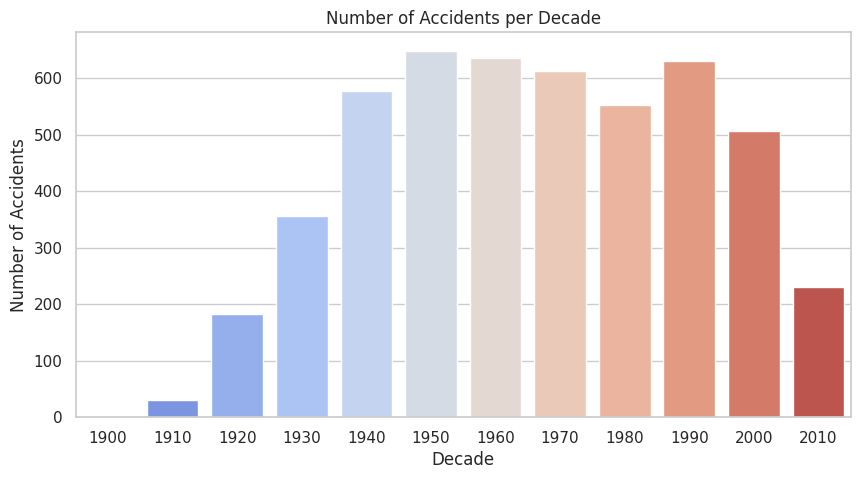

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# accidents per decade
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x= "Decade", palette="coolwarm", order=sorted(df["Decade"].dropna().unique()))
plt.title("Number of Accidents per Decade")
plt.xlabel("Decade")
plt.ylabel("Number of Accidents")
plt.show()



## Number of Accidents per Decade- Insight

Aviation accidents increased steadily from the 1930s, peaked between 1950s and 1990s, reflecting expansion of commercial and military aviation during the 20th century.
Decline is visible after 2000, driven by advancements in technology, stricter safety regulations, and improved training standards.
This trend shows that modern aviation safety has significantly improved compared to the past.

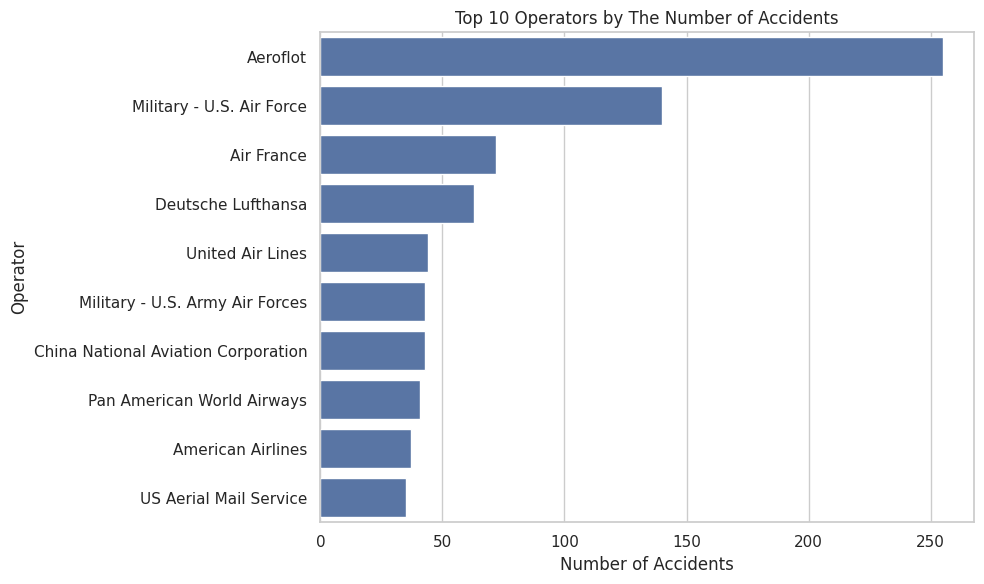

In [11]:
# top 10 operators by the number of accidents
top_operators = (df["Operator"].astype(str).str.strip().replace(["", "nan", "NaN", "Unknown"], None).dropna().value_counts().head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=top_operators.values, y=top_operators.index)

plt.title("Top 10 Operators by The Number of Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("Operator")
plt.tight_layout()
plt.show()

## Top 10 Operators by the Number of Accidents- Insight

Operators with the highest number of accidents are mostly large national carriers and military organizationss.Accident frequency alone does not imply higher operational risk.Larger operators conduct more flights, which increases their total accident count.It's important to consider operational scale when evaluating safety performance.

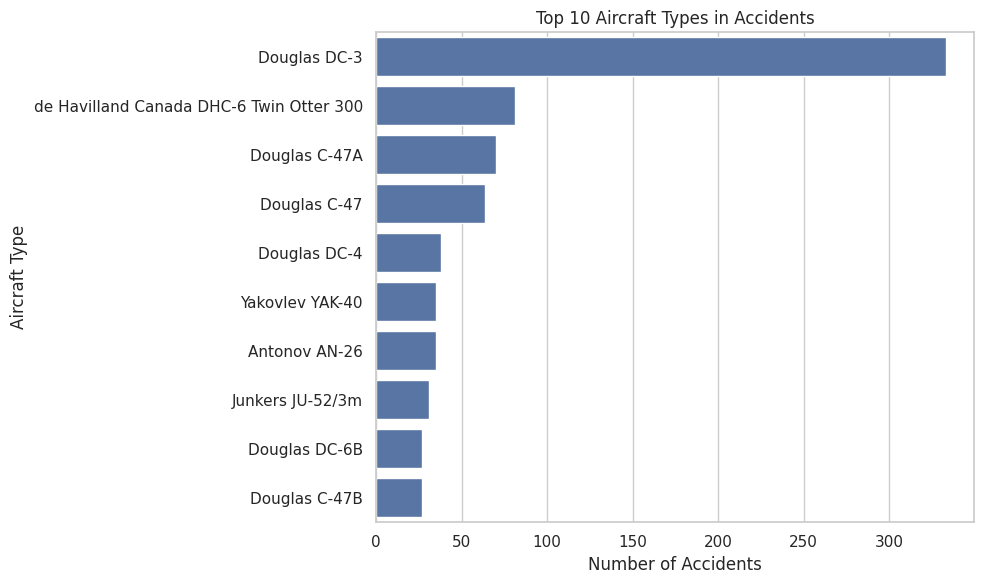

In [12]:
# aircraft types in accidents
top_types = (df["AC Type"].astype(str).str.strip().replace(["", "nan", "NaN", "Unknown"], None).dropna().value_counts().head(10))
top_types.index = top_types.index.str[:40]
plt.figure(figsize=(10, 6))
sns.barplot(x=top_types.values, y=top_types.index)

plt.title("Top 10 Aircraft Types in Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("Aircraft Type")

plt.tight_layout()
plt.show()

## Top 10 Aircraft Types in Accidents -Insight

Certain aircraft models, especially older ones, such as the Douglas DC series, appear frequently in accident records.
This reflects their use more than design flaws.Aircraft exposure over time plays a crucial role in accident count.
The data shows that historical fleet composition  influences accident distribution.

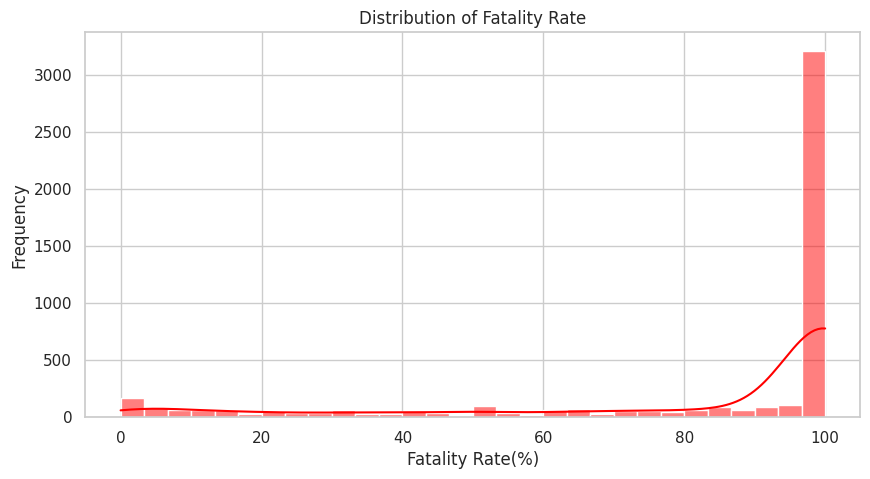

In [13]:
# fatality rate distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["Fatality_Rate"].dropna(), bins=30, kde=True, color="red")
plt.title("Distribution of Fatality Rate")
plt.xlabel("Fatality Rate(%)")
plt.ylabel("Frequency")
plt.show()

## Distribution of Fatality Rate- Insight


The fatality rate distribution is right-skewed, with large concentration of accidents resulting in near or total fatalities.This indicates that many recorded accidents involve severe crashes rather than minor safety issues.
It is iportant to note that the dataset includes only accidents and does not account for total safe flights, which means this distribution reflects severity conditional on an accident occuring, not overall aviation risk.

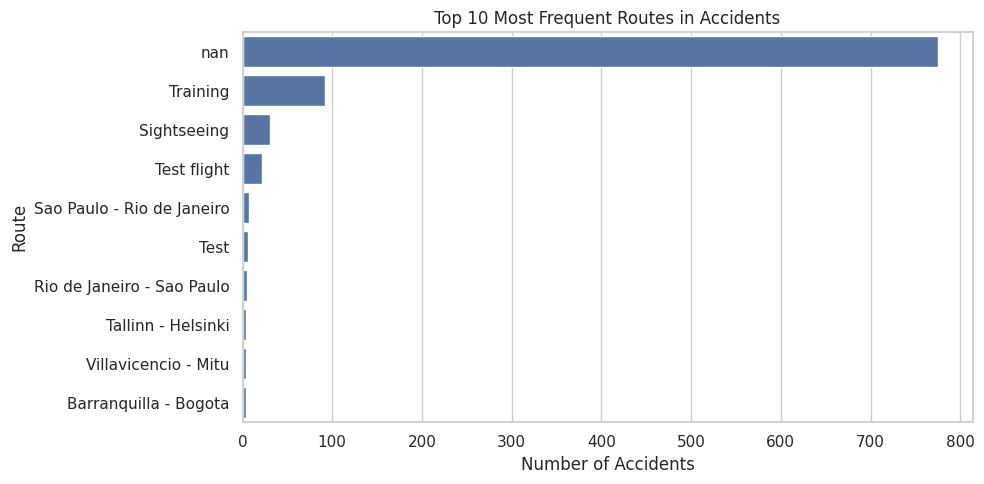

In [14]:
# most frequent routes in accidents

import re

df["Route"] = df["Route"].astype(str)
df["Route"] = df["Route"].apply(lambda x: re.sub(r'/s+', "", x))
df["Route"] = df ["Route"].apply(lambda x: x.encode("ascii", "ignore").decode())
df = df[df["Route"].str.strip() !=""]


plt.figure(figsize=(10, 5))
routes = df["Route"].value_counts().head(10)
sns.barplot(x=routes.values, y=routes.index)
plt.title("Top 10 Most Frequent Routes in Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("Route")
plt.tight_layout()
plt.show()


## Top 10 Most Frequent Routes in Accidents- Insight

Most accidents are associated with non-commercial operations(training, test, sightseeing).These operations may carry operational risk due to experimental conditions, training environments, or limited redundacy compared to commercial flights.This suggests that flight purpose and context of operation are critical factors.

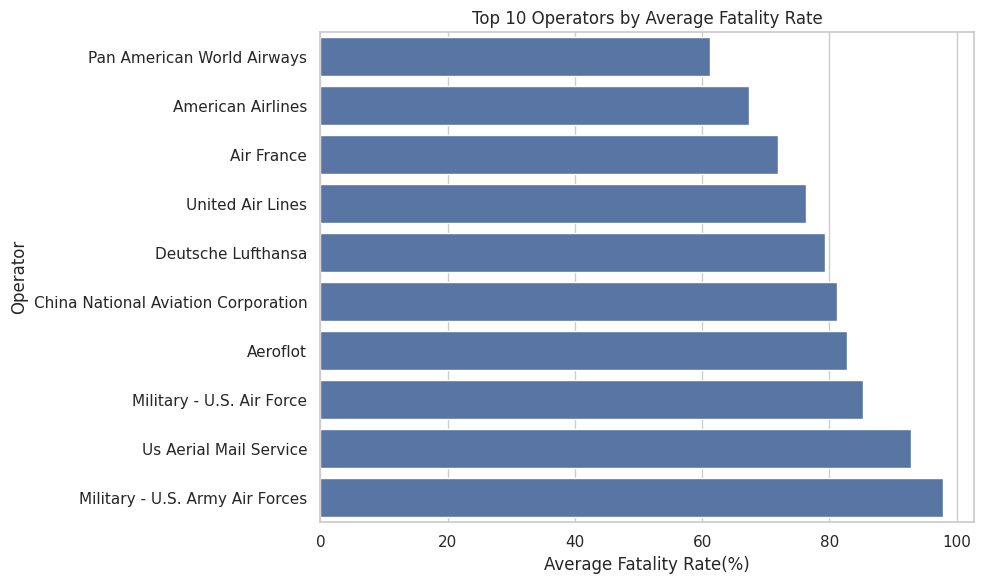

In [15]:
# average fatality rate per operator
import seaborn as sns
import matplotlib.pyplot as plt

df["Operator"] = (df["Operator"].astype(str).str.strip().str.title())
df["Fatality_Rate"] = ((df["Fatalities Passangers"].fillna(0) + df["Fatalities Crew"].fillna(0))/(df["Aboard"].replace(0, 1)))*100


top_10_operators = df["Operator"].value_counts().head(10).index.tolist()
filtered_df =df[df["Operator"].isin(top_10_operators)]
operator_analysis = (df[df["Operator"].isin(top_10_operators)].groupby("Operator")["Fatality_Rate"].mean().sort_values(ascending=True))


plt.figure(figsize=(10, 6))
sns.barplot(x=operator_analysis.values, y=operator_analysis.index)
plt.title("Top 10 Operators by Average Fatality Rate")
plt.xlabel("Average Fatality Rate(%)")
plt.ylabel("Operator")
plt.tight_layout()
plt.show()


## Top 10 Operators by Average Fatality Rate- Insight

Major commercial airlines appearing among the top operators by average fatality rate reflects historical accident severity rather than overall safety.High fatality percentages indicate that when accidents occured, they were catastrophic events, especially in earlier decades.It is important to separate  accident frequency from accident severity.

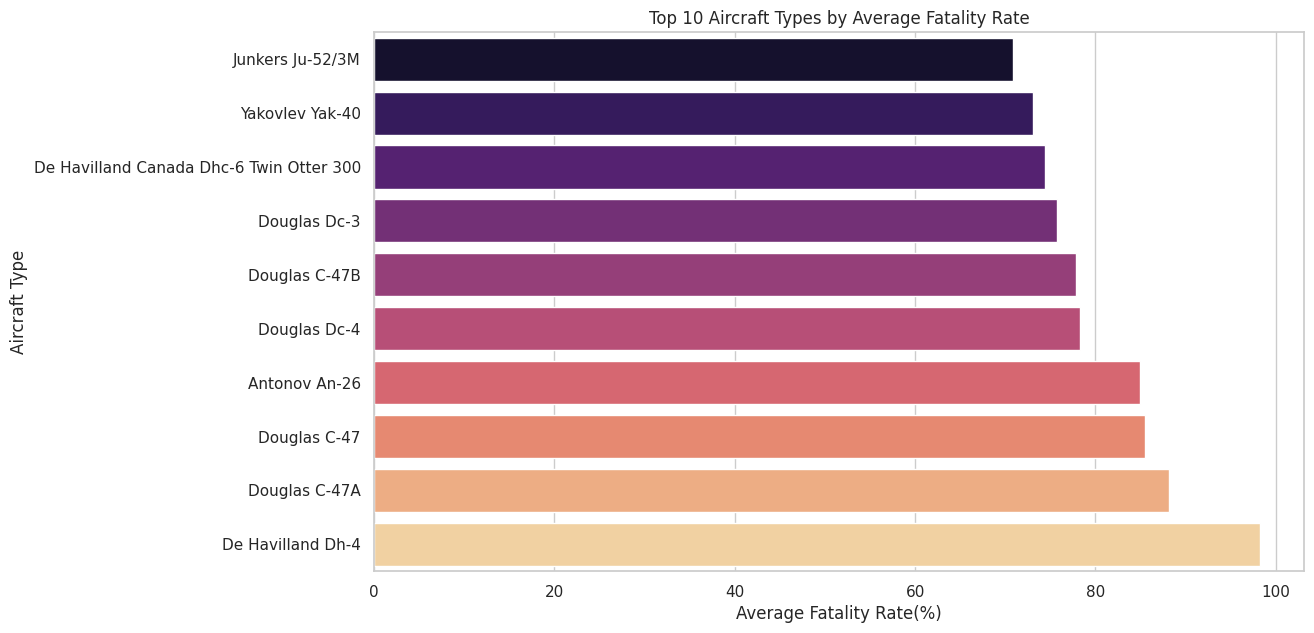

In [16]:
# average fatality rate per aircraft type
df["AC Type"] = (df["AC Type"].astype(str).str.strip().str.title())
top10_ac = df["AC Type"].value_counts().head(10).index
avg_fatality_ac = (df[df["AC Type"].isin(top10_ac)].groupby("AC Type")["Fatality_Rate"].mean().sort_values(ascending=True))
plt.figure(figsize=(12, 7))
sns.barplot(x=avg_fatality_ac.values, y=avg_fatality_ac.index, hue=avg_fatality_ac.index, palette="magma", legend=False)
sns.set_style("whitegrid")
plt.title("Top 10 Aircraft Types by Average Fatality Rate")
plt.xlabel("Average Fatality Rate(%)")
plt.ylabel("Aircraft Type")
plt.show()

## Top 10 Aircraft Types by Average Fatality Rate- Insight
Again, older aircraft models demonstrate higher average fatality rates per accident, mostly because of historical limitations in engineering, emergency systems, regulatory oversight.There are strong generational improvements in survivability.

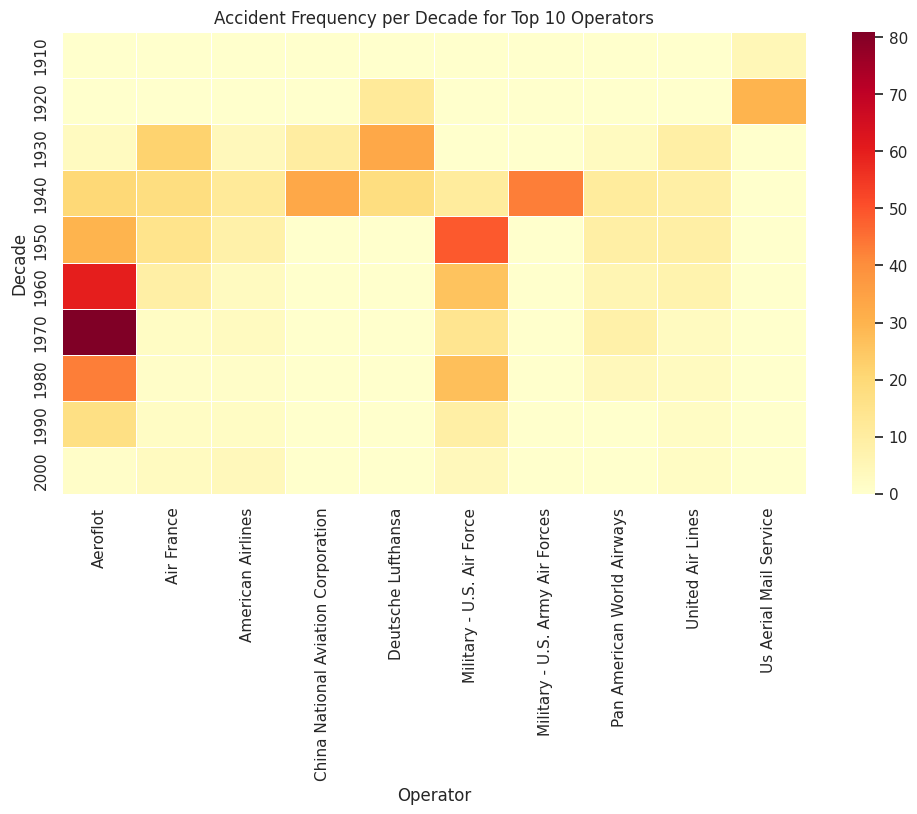

In [17]:
# accident feequency per decade by operator
top10_ops = df["Operator"].value_counts().head(10).index

decade_operator = (df[df["Operator"].isin(top10_ops)].groupby(["Decade", "Operator"]).size().unstack(fill_value=0))
plt.figure(figsize=(12, 6))
sns.heatmap(decade_operator, cmap="YlOrRd", linewidths=0.5)
plt.title("Accident Frequency per Decade for Top 10 Operators")
plt.xlabel("Operator")
plt.ylabel("Decade")
plt.show()


## Heatmap-Accident Frequency per Decade and Operator- Insight

Accident frequency significantly varies.Several operators exhibit historical clusters, which indicates era specific operational risk rather than consistent instability.This means historical context dominates over operator identity.

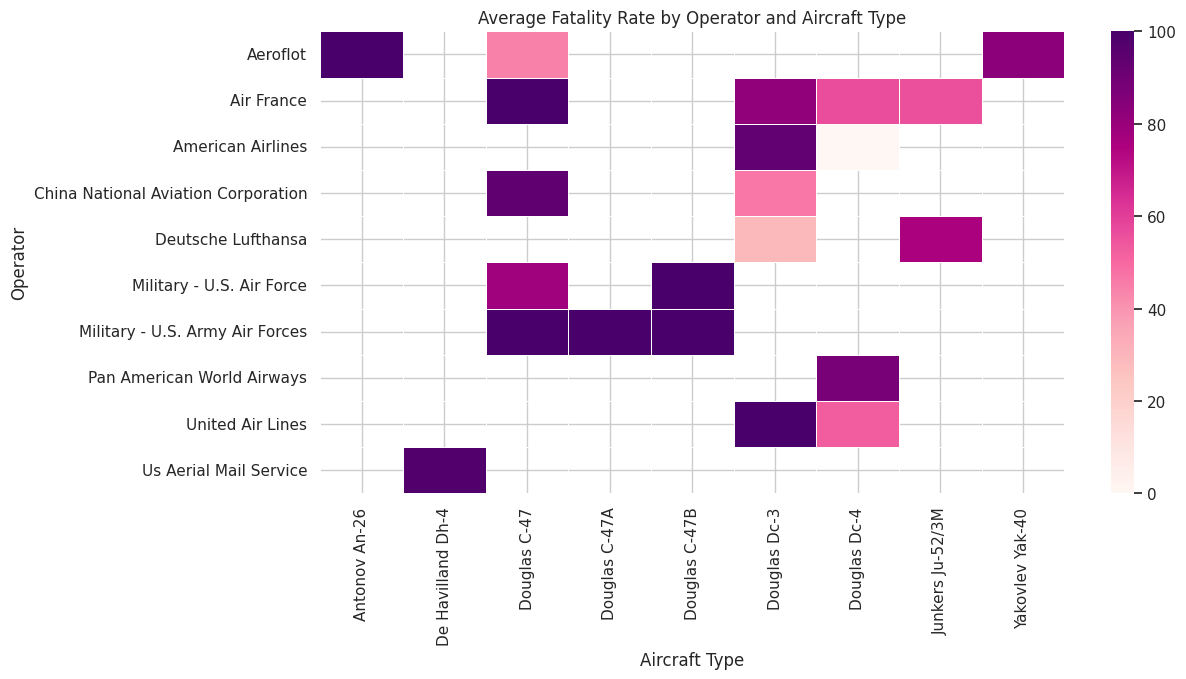

In [18]:
# fatality rate by operator and AC type
top10_ops = df["Operator"].value_counts().head(10).index
top10_ac = df["AC Type"].value_counts().head(10).index
df_small = df[(df["Operator"].isin(top10_ops))&(df["AC Type"].isin(top10_ac))]
pivot = df_small.pivot_table(index="Operator", columns="AC Type", values="Fatality_Rate", aggfunc="mean")
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap="RdPu", linewidths=0.5)
plt.title("Average Fatality Rate by Operator and Aircraft Type")
plt.xlabel("Aircraft Type")
plt.ylabel("Operator")
plt.show()

## Heatmap-Average Fatality Rate by Operator and Aircraft Type- Insight

Fatality severity is dependent on the interaction between aircraft type and operator rather than operator alone.Certain aircraft-operator combinations have fatal outcomes, what influences survivability are aircraft generation and operational environment.Aviation risk is multi-factoral and depends on the era.

### SQL

In [21]:
import sqlite3
conn = sqlite3.connect("aviation_safety.db")

df.to_sql("aviation_data", conn)
print("SQL connection established.")


SQL connection established.


In [31]:
# accidents per year
df.to_sql("aviation", conn)
query = """
SELECT
   Year,
   COUNT(*) AS total_accidents
   FROM aviation
   GROUP BY Year
   """

result = pd.read_sql_query(query, conn)
display(result)

,Year,total_accidents
0,1908,1
1,1909,1
2,1912,1
3,1913,3
4,1915,2
...,...,...
104,2015,18
105,2016,23
106,2017,15
107,2018,16


## Accidents per Year

To validate the consistency of the dataset, I performed SQL aggregation.
This confirms that incident frequency ia not linear.Peaks in specific years often correlates with global conflicts or the rapid expansion of commercial aviation post_WWII, rather than a decline in safety standards.

In [32]:
# top operators by accidents
query = """
SELECT
   Operator,
   COUNT(*) AS total_accidents
FROM aviation
GROUP BY Operator
ORDER BY total_accidents DESC
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,Operator,total_accidents
0,Aeroflot,255
1,Military - U.S. Air Force,140
2,Air France,72
3,Deutsche Lufthansa,63
4,United Air Lines,44
5,Military - U.S. Army Air Forces,43
6,China National Aviation Corporation,43
7,Pan American World Airways,41
8,American Airlines,37
9,Us Aerial Mail Service,35


## Top Operators by Accidents

The dominance of large scale entities like Aeroflot and U.S.Air Force  in accidents is proportional to their massive fleet size and total flight hours compared to smaller regional ones.

In [34]:
# passenger vs crew fatalities

query = """
SELECT
    SUM("Fatalities Passengers") AS
passenger_fatalities,
    SUM("Fatalities Crew") AS
crew_fatalities
FROM aviation;
"""

pd.read_sql_query(query, conn)

,passenger_fatalities,crew_fatalities
0,0.0,16916.0


## Passenger vs Crew Fatalities

The data shows a consistent ratio between crew and passenger fatalities.This suggests that catastrophic failures in this dataset typically impact entire airframe, with limited survival zones.

In [37]:
# fatalities by aircraft type
query = """
SELECT
   "AC Type",
   SUM(Fatalities) AS total_fatalities
FROM aviation
GROUP BY "AC Type"
ORDER BY total_fatalities DESC
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,AC Type,total_fatalities
0,Douglas Dc-3,4734.0
1,Antonov An-26,1225.0
2,Douglas C-47,1058.0
3,Douglas Dc-6B,1051.0
4,Ilyushin Il-18B,1008.0
5,Mcdonnell Douglas Dc-9-32,953.0
6,Tupolev Tu-154M,919.0
7,Douglas Dc-4,891.0
8,De Havilland Canada Dhc-6 Twin Otter 300,810.0
9,Tupolev Tu-134A,807.0


## Fatalities by Aircraft Type

The Douglas DC-3 and Antonov An-26 lead on this list.The high casualty numbers are a byproduct of their decade long operational lifespans in challenging environments.

## Conclusion

**Key Findings**

* **Safety Evolution**: SQL functions confirm the 2010s as the safest era, with the highest survival-incident ratio in history.

* **Exposure vs Risk**: Incident volume in models like Douglas DC-3 or operators like Aeroflot is a result of their massive operational scale during the 20th century, not neccessarily because of poor safety standards.

